# **Analyse et Ingénierie des données de la chlordécone aux Antilles françaises**

# Notebook 6 – Synthèse finale & Aide à la décision
**Projet Chlordécone – Antilles françaises**


Ce notebook a pour objectif de faire une synthèse accessible des résultats obtenus au cours de cette étude sur la contamination au chlordécone en Martinique. 


Pour rappel le **chlordécone** est un pesticide utilisé dans les bananeraies des Antilles françaises jusqu'en 1993. Très persistant dans les sols, il est aujourd'hui classé comme **perturbateur endocrinien** et **cancérogène possible**. Sa présence dans les sols agricoles pose un problème sanitaire, environnemental et économique majeur pour la Martinique et la Guadeloupe.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# Chemins relatifs pour la reproductibilité
NOTEBOOK_DIR = os.getcwd()
FIG_DIR = os.path.join(NOTEBOOK_DIR, 'fig', '6-synthese_finale')
os.makedirs(FIG_DIR, exist_ok=True)

# Chargement (séparateur point-virgule, format CSV français)
df = pd.read_csv(
    os.path.join(NOTEBOOK_DIR, 'BaseCLD2026.csv'),
    sep=';',
    parse_dates=['Date_prelevement', 'Date_enregistrement', 'Date_analyse']
)

# Conversion numérique des colonnes lues comme str
cols_numeriques = ['Taux_Chlordecone', 'Taux_5b_hydro', 'histoBanane_Histo_ban',
                   'mnt_tpi_mean', 'mnt_tri_mean', 'mnt_rugosite_mean',
                   'mnt_ombrage_mean', 'mnt_exposition_mean', 'mnt_pente_mean']
for col in cols_numeriques:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['log_Taux'] = np.log1p(df['Taux_Chlordecone'])

# Catégorisation selon les seuils réglementaires
def categoriser(taux):
    if pd.isna(taux):    return np.nan
    elif taux < 0.1:     return 'Faible (< 0.1 mg/kg)'
    elif taux < 1.0:     return 'Modéré (0.1–1.0 mg/kg)'
    else:                return 'Élevé (≥ 1.0 mg/kg)'

df['categorie'] = df['Taux_Chlordecone'].apply(categoriser)

print(f'Données chargées : {df.shape[0]:,} lignes × {df.shape[1]} colonnes')

Données chargées : 31,126 lignes × 24 colonnes


## 1. Chiffres clés

Une première lecture des données pour comprendre l'ampleur de la contamination.

In [5]:
total         = len(df)
pct_eleve     = (df['Taux_Chlordecone'] >= 1.0).mean() * 100
pct_modere    = ((df['Taux_Chlordecone'] >= 0.1) & (df['Taux_Chlordecone'] < 1.0)).mean() * 100
pct_faible    = (df['Taux_Chlordecone'] < 0.1).mean() * 100
nb_communes   = df['COMMU_LAB'].nunique()
taux_moyen    = df['Taux_Chlordecone'].mean()

print('╔══════════════════════════════════════════════╗')
print('║         CHIFFRES CLÉS DE L\'ÉTUDE             ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Parcelles analysées     : {total:>10,}        ║')
print(f'║  Communes concernées     : {nb_communes:>10}        ║')
print(f'║  Période couverte        :  2010 – 2019      ║')
print(f'║  Taux moyen              : {taux_moyen:>9.3f} mg/kg   ║')
print('╠══════════════════════════════════════════════╣')
print(f'║  Parcelles faiblement contaminées  : {pct_faible:>5.1f}%  ║')
print(f'║  Parcelles modérément contaminées  : {pct_modere:>5.1f}%  ║')
print(f'║  Parcelles fortement contaminées   : {pct_eleve:>5.1f}%  ║')
print('╚══════════════════════════════════════════════╝')

╔══════════════════════════════════════════════╗
║         CHIFFRES CLÉS DE L'ÉTUDE             ║
╠══════════════════════════════════════════════╣
║  Parcelles analysées     :     31,126        ║
║  Communes concernées     :         35        ║
║  Période couverte        :  2010 – 2019      ║
║  Taux moyen              :     0.668 mg/kg   ║
╠══════════════════════════════════════════════╣
║  Parcelles faiblement contaminées  :  65.3%  ║
║  Parcelles modérément contaminées  :  16.8%  ║
║  Parcelles fortement contaminées   :  17.9%  ║
╚══════════════════════════════════════════════╝


## 2. Visualisations de synthèse

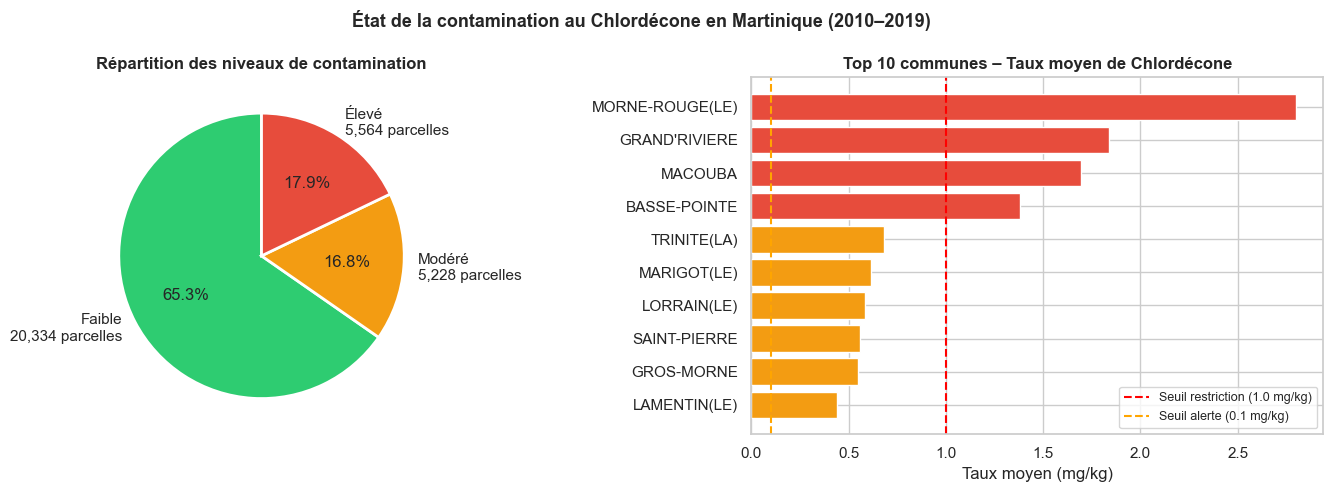

In [6]:
# ── Graphique 1 : Répartition des niveaux de contamination ──────────────
cat_counts = df['categorie'].value_counts().reindex([
    'Faible (< 0.1 mg/kg)', 'Modéré (0.1–1.0 mg/kg)', 'Élevé (≥ 1.0 mg/kg)'
])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].pie(
    cat_counts.values,
    labels=[f"{c.split('(')[0].strip()}\n{v:,} parcelles" for c, v in zip(cat_counts.index, cat_counts.values)],
    colors=colors, autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Répartition des niveaux de contamination', fontweight='bold')

# ── Graphique 2 : Top 10 communes les plus contaminées ───────────────────
top10 = df.groupby('COMMU_LAB')['Taux_Chlordecone'].mean().sort_values(ascending=False).head(10)
bar_colors = ['#e74c3c' if v >= 1.0 else '#f39c12' for v in top10.values]

axes[1].barh(top10.index[::-1], top10.values[::-1], color=bar_colors[::-1], edgecolor='white')
axes[1].axvline(x=1.0, color='red',    linestyle='--', linewidth=1.5, label='Seuil restriction (1.0 mg/kg)')
axes[1].axvline(x=0.1, color='orange', linestyle='--', linewidth=1.5, label='Seuil alerte (0.1 mg/kg)')
axes[1].set_title('Top 10 communes – Taux moyen de Chlordécone', fontweight='bold')
axes[1].set_xlabel('Taux moyen (mg/kg)')
axes[1].legend(fontsize=9)

plt.suptitle('État de la contamination au Chlordécone en Martinique (2010–2019)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_synthese_contamination.png'), dpi=150, bbox_inches='tight')
plt.show()

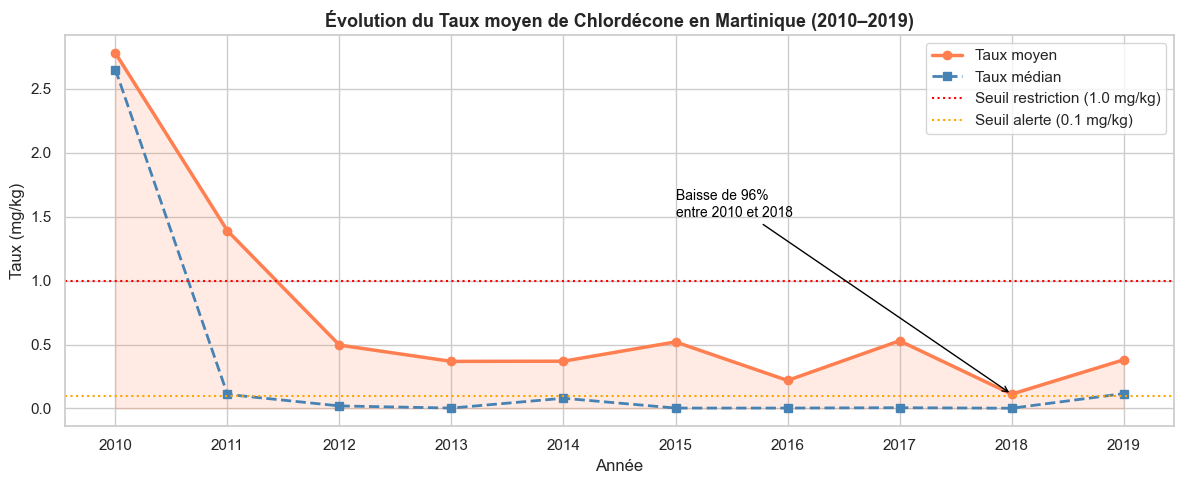

In [7]:
# ── Graphique 3 : Évolution temporelle ───────────────────────────────────
agg_annee = df.groupby('ANNEE')['Taux_Chlordecone'].agg(['mean', 'median']).reset_index()

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(agg_annee['ANNEE'], agg_annee['mean'], alpha=0.15, color='coral')
ax.plot(agg_annee['ANNEE'], agg_annee['mean'],   marker='o', color='coral',     linewidth=2.5, label='Taux moyen')
ax.plot(agg_annee['ANNEE'], agg_annee['median'], marker='s', linestyle='--', color='steelblue', linewidth=2, label='Taux médian')
ax.axhline(y=1.0, color='red',    linestyle=':', linewidth=1.5, label='Seuil restriction (1.0 mg/kg)')
ax.axhline(y=0.1, color='orange', linestyle=':', linewidth=1.5, label='Seuil alerte (0.1 mg/kg)')

ax.annotate('Baisse de 96%\nentre 2010 et 2018',
            xy=(2018, 0.112), xytext=(2015, 1.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, color='black')

ax.set_title('Évolution du Taux moyen de Chlordécone en Martinique (2010–2019)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Taux (mg/kg)')
ax.set_xticks(agg_annee['ANNEE'])
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_synthese_evolution.png'), dpi=150, bbox_inches='tight')
plt.show()

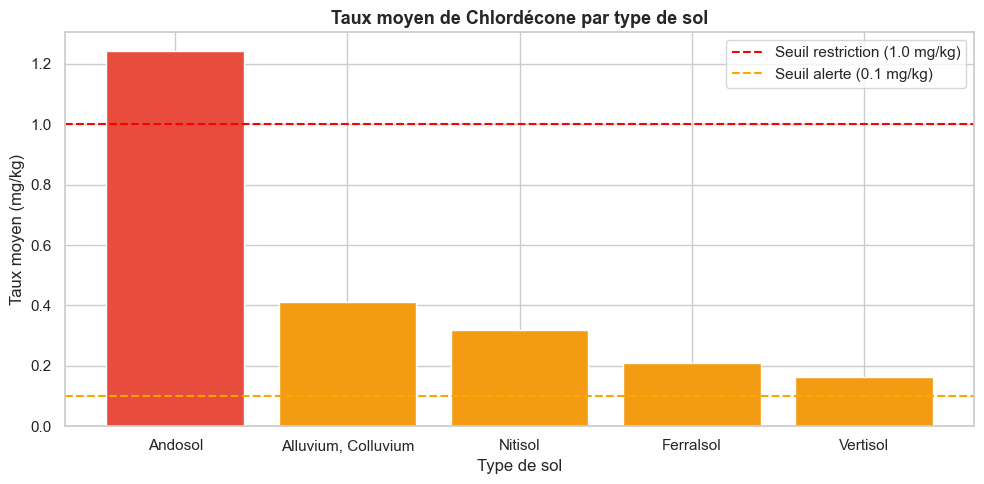

In [8]:
# ── Graphique 4 : Contamination par type de sol ───────────────────────────
sol_stats = df.groupby('Sol_simple')['Taux_Chlordecone'].mean().sort_values(ascending=False).dropna()
sol_stats = sol_stats[~sol_stats.index.isin(['No data', 'Urban area'])]

bar_colors = ['#e74c3c' if v >= 1.0 else '#f39c12' if v >= 0.1 else '#2ecc71' for v in sol_stats.values]

plt.figure(figsize=(10, 5))
plt.bar(sol_stats.index, sol_stats.values, color=bar_colors, edgecolor='white')
plt.axhline(y=1.0, color='red',    linestyle='--', linewidth=1.5, label='Seuil restriction (1.0 mg/kg)')
plt.axhline(y=0.1, color='orange', linestyle='--', linewidth=1.5, label='Seuil alerte (0.1 mg/kg)')
plt.title('Taux moyen de Chlordécone par type de sol', fontsize=13, fontweight='bold')
plt.xlabel('Type de sol')
plt.ylabel('Taux moyen (mg/kg)')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fig_synthese_sol.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3. Récapitulatif des principaux résultats

### Ce que les données nous disent

**Sur l'ampleur de la contamination**
- Près d'**1 parcelle sur 5** (17.9%) dépasse le seuil de restriction de 1.0 mg/kg, au-delà duquel la culture de légumes racines est interdite.
- Plus d'**1 parcelle sur 3** (34.7%) dépasse le seuil d'alerte de 0.1 mg/kg.
- Le taux maximum mesuré atteint **17.35 mg/kg**, soit 17 fois le seuil de restriction.

**Sur la localisation**
- Les communes du **nord de la Martinique** sont les plus touchées : Morne-Rouge, Grand'Rivière, Macouba, Basse-Pointe.
- Ces zones correspondent aux **zones de montagne avec forte pluviométrie** (3000–5000 mm/an) où les bananeraies étaient historiquement concentrées.

**Sur le type de sol**
- Les **Andosols** (sols volcaniques) présentent le taux moyen le plus élevé (1.24 mg/kg), car ils retiennent particulièrement bien le chlordécone.
- Les **Vertisols** et **Ferralsols** sont moins contaminés (< 0.25 mg/kg).

**Sur l'évolution dans le temps**
- Le taux moyen a **baissé de 96%** entre 2010 (2.78 mg/kg) et 2018 (0.11 mg/kg).
- Cette baisse s'explique en partie par l'augmentation des prélèvements dans des zones moins contaminées, et non uniquement par une dépollution réelle des sols.

## 4. Recommandations pour la prise de décision publique

Sur la base des résultats de cette analyse, voici les actions prioritaires identifiées :

### 🔴 Priorité haute – Actions immédiates

**1. Cibler les communes du nord en priorité**
Les communes de Morne-Rouge, Grand'Rivière, Macouba et Basse-Pointe dépassent largement le seuil de restriction. Un suivi renforcé et des restrictions agricoles ciblées sont nécessaires dans ces zones.

**2. Surveiller spécifiquement les Andosols**
Ces sols volcaniques retiennent le chlordécone plus longtemps. Les agriculteurs cultivant sur Andosols devraient bénéficier d'un accompagnement prioritaire pour adapter leurs pratiques.

### 🟡 Priorité moyenne – Actions à moyen terme

**3. Maintenir et étendre le réseau de prélèvements**
Le nombre de prélèvements a fortement varié selon les années (1 163 en 2011 vs 8 567 en 2018). Un réseau de surveillance stable et régulier permettrait de mieux suivre l'évolution réelle de la contamination.

**4. Croiser avec des données de santé publique**
Cette étude porte uniquement sur les sols. Un croisement avec des données épidémiologiques (cancers, troubles hormonaux) permettrait de mieux évaluer l'impact sanitaire réel sur les populations.

### 🟢 Priorité basse – Perspectives long terme

**5. Évaluer les techniques de dépollution**
Des expérimentations de phytoremédiation (utilisation de plantes pour absorber les polluants) sont en cours. Les données de cette étude pourraient servir de baseline pour mesurer leur efficacité.

**6. Sensibiliser les agriculteurs**
34.7% des parcelles dépassent le seuil d'alerte mais leurs propriétaires ne le savent pas forcément. Une campagne d'information ciblée permettrait d'adapter les cultures en conséquence.

## 5. Limites de l'étude et perspectives

### Limites

- **Biais de sélection** : les parcelles prélevées ne sont pas choisies aléatoirement. Les zones les plus contaminées sont potentiellement sur-représentées car elles font l'objet de plus de contrôles.

- **Données manquantes** : 57% des valeurs d'historique bananier sont manquantes, ce qui limite l'analyse de l'impact des anciennes cultures sur la contamination actuelle.

- **Pas de données de santé** : cette étude se limite aux sols. Elle ne permet pas de conclure sur l'exposition réelle des populations ni sur les impacts sanitaires.

- **Résolution spatiale** : les coordonnées sont ponctuelles (une mesure par emplacement). Une cartographie continue nécessiterait des techniques d'interpolation spatiale (krigeage).

### Perspectives

- Appliquer des **modèles de machine learning** pour prédire le taux de contamination d'une parcelle à partir de ses caractéristiques (sol, pente, pluviométrie, historique).
- Intégrer des **données satellitaires** pour croiser l'occupation des sols avec les niveaux de contamination.
- Étendre l'analyse à la **Guadeloupe**, également touchée par la chlordécone.